# Latent segmentation: fine-tuned with an unfrozen head variants against the baseline (axis-200-900)

Do the held-out images segment differently in the latent space of a pretrained variant than in the baseline latent space? Stage shown: **fine-tuned with an unfrozen head**, i.e. the pretrained model after 10 epochs on the real training data with every parameter trainable.

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "stage_segmentation"
AXIS = "axis-200-900"
STAGE = "unfrozen_head"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]
EVALUATIONS = ['test', 'test_combined', 'heldout_image', 'heldout_image_per_image']

ranking = load_table(settings, 'stage_overview', 'variant_ranking', AXIS, STAGE).sort_values('rank')
TOP = ranking.variant.head(3).tolist()
SHOWN = [BASELINE, *TOP]
print('Representatives:', metadata['representatives'])
print('Shown in the maps (baseline and the three best-ranked variants):', SHOWN)

Analysis: stage_segmentation | axis: axis-200-900 | stage: unfrozen_head | models: 55
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}
Representatives: {'baseline': 'metaspace-pretrain-repaired-20260923-01__grid_0000__rep_02__real_only', 'P0_single': 'metaspace-pretrain-repaired-20260923-01__grid_0001__rep_02__unfrozen_head', 'P1_permutation': 'metaspace-pretrain-repaired-20260923-01__grid_0002__rep_02__unfrozen_head', 'P2_joint_base': 'metaspace-pretrain-repaired-20260923-01__grid_0003__rep_00__unfrozen_head', 'P2_staged_base': 'metaspace-pretrain-repaired-20260923-01__grid_0004__rep_02__unfrozen_head', 'P3_joint_overlap': 'metaspace-pretrain-repaired-20260923-01__grid_0005__rep_03__unfrozen_head', 'P3_staged_overlap': 'metaspace-pretrain-repaired-20260923-01__grid_0006__rep_03__unfrozen_head', 'P4_joint_rare': 'metaspace-pretrain-repaired-20260923-01__grid_0007__rep_04__unfrozen_hea

## Producing the tables this notebook reads

### Methodology

#### Implementation

`stage_segmentation` fits Gaussian mixtures (part 1_07 implementation, seeded) on a training sample of every
representative's latent codes for each $k$, labels the held-out pixels and aligns every partition to the
baseline representative's partition of the same $k$ (Hungarian matching on the contingency table).

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis stage_segmentation > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Segmentations of every variant against the real-only baseline

### Methodology

#### Theoretical

The agreement of every variant's latent segmentation with the baseline's (ARI; 1 = identical partition) and the
mixture fit (BIC) of every representation, as levels per number of segments.

#### Implementation

`agreement` (ARI of each representative's held-out partition to the baseline representative's, per $k$) and `bic`.

#### Figure descriptions

        Figure: one panel per $k$, ARI to the baseline per variant (dashed line = baseline, 1 by definition when
        present). Table: BIC per $k$ (lower = better fit; comparable only within one $k$).

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

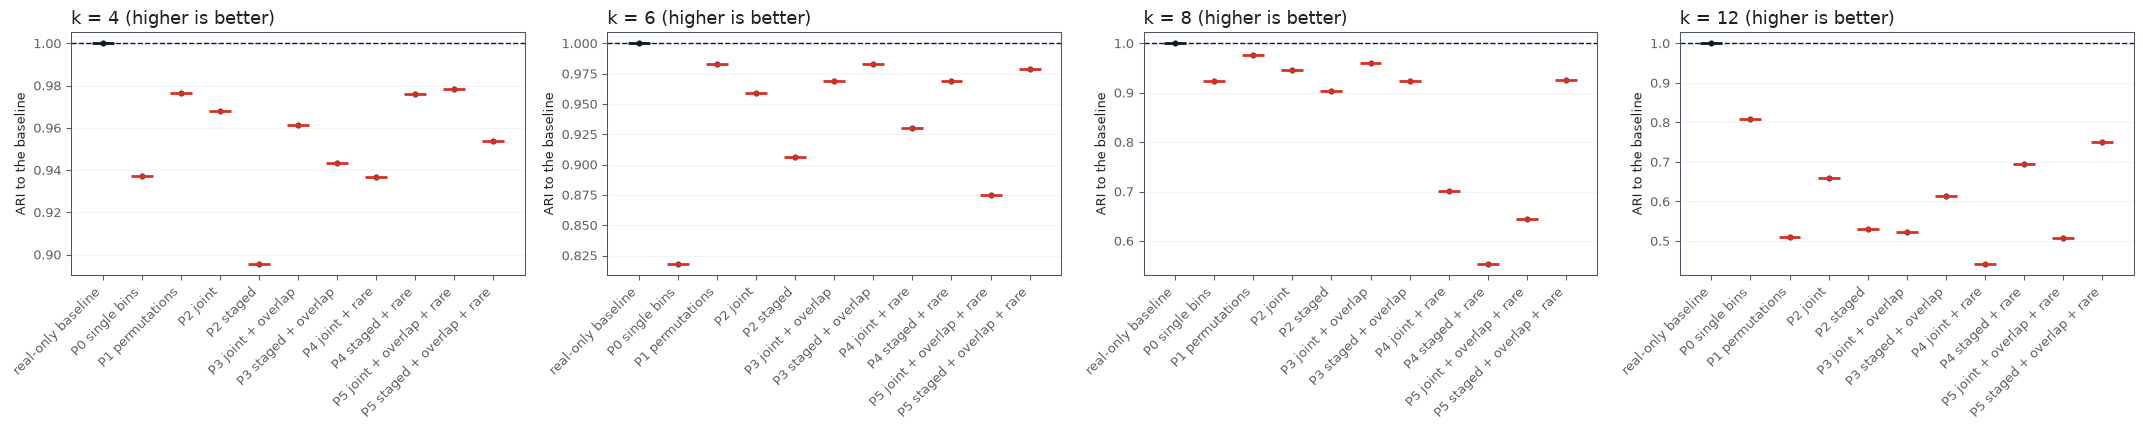

column,k = 12,k = 4,k = 6,k = 8
variant,,,,
baseline,-355724 +/- -,-219016 +/- -,-278751 +/- -,-314385 +/- -
P0_single,-411875 +/- -,-267108 +/- -,-325749 +/- -,-371795 +/- -
P1_permutation,-364741 +/- -,-225806 +/- -,-275258 +/- -,-325224 +/- -
P2_joint_base,-381822 +/- -,-235399 +/- -,-293607 +/- -,-339896 +/- -
P2_staged_base,-434609 +/- -,-284003 +/- -,-349338 +/- -,-369688 +/- -
P3_joint_overlap,-389282 +/- -,-260357 +/- -,-317794 +/- -,-352903 +/- -
P3_staged_overlap,-354365 +/- -,-218517 +/- -,-280557 +/- -,-321549 +/- -
P4_joint_rare,-388655 +/- -,-249584 +/- -,-307392 +/- -,-342881 +/- -
P4_staged_rare,-378154 +/- -,-235817 +/- -,-304461 +/- -,-329844 +/- -


In [4]:
agreement_abs = table('agreement').rename(columns={'ari_to_baseline': 'value'})
ks = sorted(agreement_abs.k.unique())
figure, axes = plt.subplots(1, len(ks), figsize=(5.4 * len(ks), 4.4), dpi=theme.figure_dpi)
for ax, k in zip(np.atleast_1d(axes), ks):
    figures.value_violins(agreement_abs[agreement_abs.k == k], value='value', group='variant', order=ABS_ORDER, labels=LABELS_ABS,
                          baseline=BASELINE, direction='higher', ylabel='ARI to the baseline', title=f'k = {k}', ax=ax, theme=theme)
figure.tight_layout()
plt.show()
bic_abs = table('bic').rename(columns={'bic': 'value'}).assign(column=lambda frame: 'k = ' + frame.k.astype(str))
display(figures.comparison_table(bic_abs, index='variant', columns='column', baseline=BASELINE, order=ABS_ORDER, digits=0,
                                 direction={column: 'lower' for column in bic_abs.column.unique()}))

### Remarks

- k = 4: ARI to the baseline representative 0.90-0.98 across variants.
- k = 6: ARI to the baseline representative 0.82-0.98 across variants.
- k = 8: ARI to the baseline representative 0.55-0.98 across variants.
- k = 12: ARI to the baseline representative 0.44-0.81 across variants.

### Notes

## Model selection: BIC per number of segments

### Methodology

#### Theoretical

Bayesian information criterion of the mixture on the training sample; lower is better. Part 1_07 showed that
BIC keeps decreasing up to $k = 12$ (grid edge), so $k$ is not selected by BIC; $k = 4$ and $6$ are shown as
in part 1.

#### Implementation

`bic` (one representative per variant and the baseline).

#### Figure descriptions

x = $k$, y = BIC, one line per model.

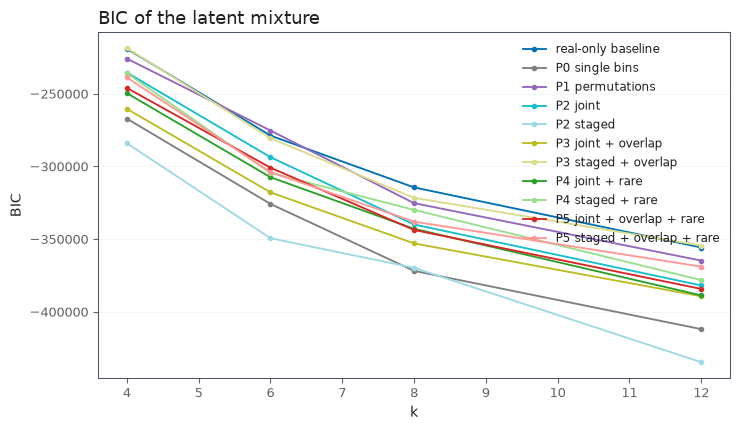

In [5]:
bic = table('bic')
figures.epoch_curves(bic, levels=ORDER, labels=VARIANT_LABELS, colors=VARIANT_COLORS, x='k', y='bic', xlabel='k', ylabel='BIC',
                     title='BIC of the latent mixture', theme=theme);

### Remarks

- BIC decreases with k for every representative (no interior minimum on the grid), as in part 1_07.

### Notes

## Agreement with the baseline segmentation

### Methodology

#### Theoretical

Adjusted Rand index between the held-out partition of a variant representative and that of the baseline
representative (1 = identical partition, 0 = chance agreement).

#### Implementation

`agreement` (per representative and $k$).

#### Figure descriptions

x = $k$, y = ARI, one line per variant; the table gives the values.

k,4,6,8,12
variant,,,,
P0_single,0.937,0.818,0.923,0.809
P1_permutation,0.977,0.983,0.976,0.511
P2_joint_base,0.968,0.959,0.947,0.660
P2_staged_base,0.895,0.907,0.904,0.530
P3_joint_overlap,0.961,0.969,0.960,0.522
P3_staged_overlap,0.943,0.983,0.925,0.614
P4_joint_rare,0.937,0.930,0.701,0.441
P4_staged_rare,0.976,0.969,0.553,0.694
P5_joint_all,0.978,0.875,0.645,0.507


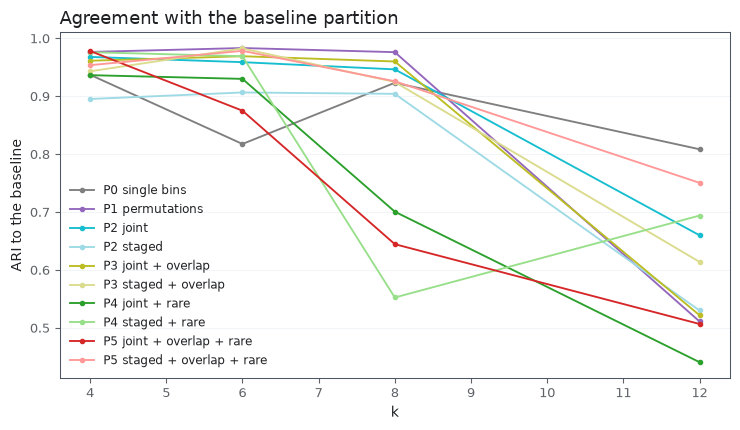

In [6]:
agreement = table('agreement')
agreement = agreement[agreement.variant != BASELINE]
figures.epoch_curves(agreement, levels=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS, x='k', y='ari_to_baseline', xlabel='k',
                     ylabel='ARI to the baseline', title='Agreement with the baseline partition', theme=theme);
display(agreement.pivot_table(index='variant', columns='k', values='ari_to_baseline').reindex(VARIANTS).round(3))

### Remarks

- k = 4: ARI to the baseline 0.9-0.98 (median 0.96).
- k = 6: ARI to the baseline 0.82-0.98 (median 0.96).
- k = 8: ARI to the baseline 0.55-0.98 (median 0.92).
- k = 12: ARI to the baseline 0.44-0.81 (median 0.57).

### Notes

## Segment maps of the held-out images

### Methodology

#### Theoretical

Aligned segment labels on the held-out images; the same colour denotes the matched segment across
models. Images show the representative repetition only (never averaged).

#### Implementation

`labels` (stored for $k \in$ `segmentation.stage_k_values`).

#### Figure descriptions

One figure per $k$: rows = held-out images, columns = baseline and the three best-ranked variants.

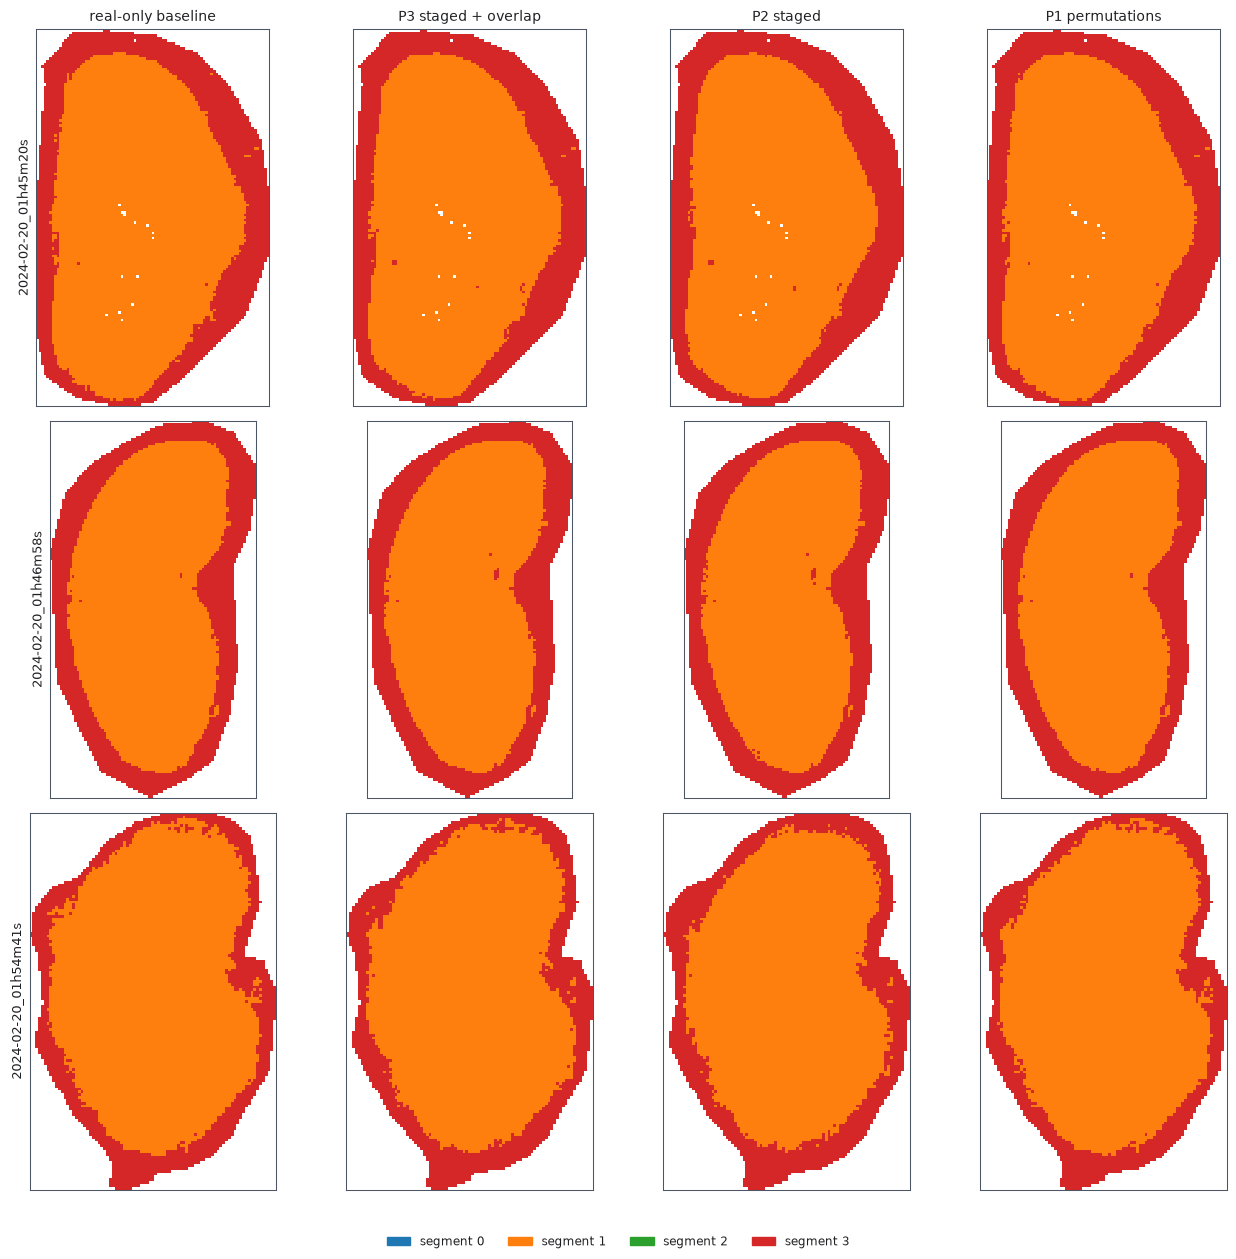

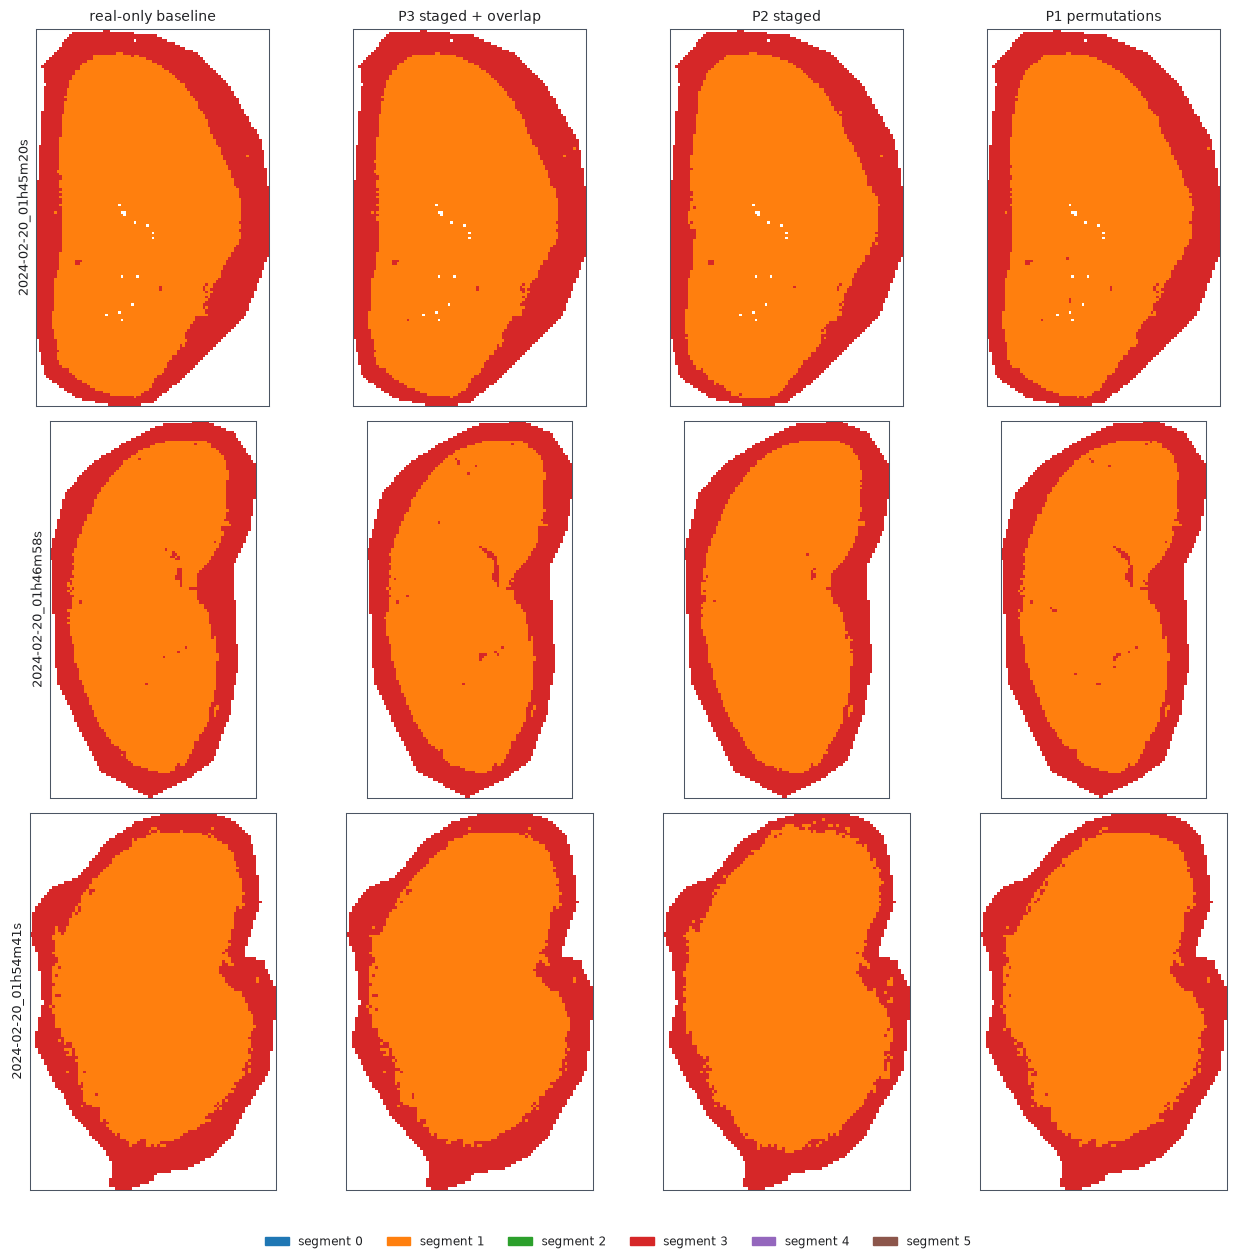

In [7]:
labels = table('labels')
DATASETS = sorted(labels.dataset_id.unique())
for k in settings['segmentation']['stage_k_values']:
    wide = labels[labels.k == k].pivot_table(index=['row', 'dataset_id', 'x', 'y'], columns='variant', values='segment').reset_index()
    figures.label_panels(wide, label_columns=SHOWN, column_titles=[VARIANT_LABELS[name] for name in SHOWN], datasets=DATASETS, k=k, theme=theme)

### Remarks

- Segments present on the held-out images: k = 4: 2-2 of 4; k = 6: 2-3 of 6 (over the baseline and all variant representatives).

### Notes

## Where the best variant splits or merges baseline segments

### Methodology

#### Theoretical

Row-normalized contingency between the baseline partition (rows) and the best variant's aligned partition
(columns): a diagonal matrix is the same segmentation; off-diagonal mass shows baseline segments that the
variant splits or merges.

#### Implementation

`contingency` (per variant and $k$, fractions of the baseline segment).

#### Figure descriptions

Heat map for the best-ranked variant at $k = 6$.

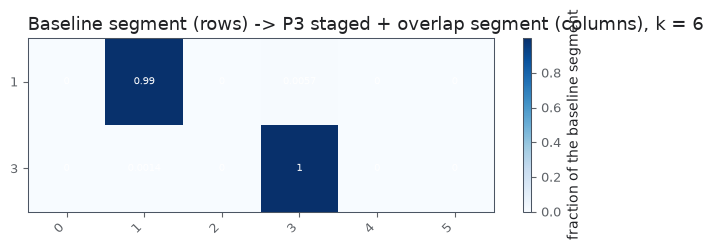

In [8]:
contingency = table('contingency')
matrix = contingency[(contingency.variant == TOP[0]) & (contingency.k == 6)].pivot_table(index='reference_segment', columns='other_segment', values='reference_fraction')
figures.matrix_heatmap(matrix, title=f'Baseline segment (rows) -> {VARIANT_LABELS[TOP[0]]} segment (columns), k = 6',
                       colorbar_label='fraction of the baseline segment', annotate=True, cmap='Blues', theme=theme);

### Remarks

- P3 staged + overlap, k = 6: 99.6 % of the held-out pixels keep their (aligned) baseline segment.

### Notes

## Results / Summary

### LLM

- **Observed:** ARI to the baseline segmentation at k = 6: 0.82-0.98 (median 0.96); the held-out images use 2-3 of the 6 segments (baseline: 2).
- **Interpretation:** the fine-tuned variants reproduce the baseline segmentation of the held-out images closely (median ARI 0.96); pretraining does not change the coarse spatial structure of the latent space.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- k = 4: ARI to the baseline representative 0.90-0.98 across variants.
- k = 6: ARI to the baseline representative 0.82-0.98 across variants.
- k = 8: ARI to the baseline representative 0.55-0.98 across variants.
- k = 12: ARI to the baseline representative 0.44-0.81 across variants.

### Person